<a href="https://colab.research.google.com/github/ahaddd-ship-it/DAV-assingment1-24/blob/main/dav1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = '/content/Quote-Equity-BAJAJFINSV-EQ-20-04-2025-20-04-2026.csv'
df = pd.read_csv(file_path)

# Display the first few rows and column info to identify column names
print("Initial Data Info:")
display(df.info())
display(df.head())

Initial Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   DATE            247 non-null    object
 1   SERIES          247 non-null    object
 2   OPEN            247 non-null    object
 3   HIGH            247 non-null    object
 4   LOW             247 non-null    object
 5   PREV. CLOSE     247 non-null    object
 6   LTP             247 non-null    object
 7   CLOSE           247 non-null    object
 8   VWAP            247 non-null    object
 9   52W H           247 non-null    object
 10  52W L           247 non-null    object
 11  VOLUME          247 non-null    int64 
 12  VALUE           247 non-null    object
 13  NO. OF  TRADES  247 non-null    int64 
dtypes: int64(2), object(12)
memory usage: 27.1+ KB


None

,DATE,SERIES,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,52W L,VOLUME,VALUE,NO. OF TRADES
0,17-Apr-2026,EQ,"1,828.80","1,845.50","1,811.70","1,829.90","1,838.00","1,838.90","1,834.03","2,195.00","1,597.00",487836,"89,47,04,272.10",31656
1,16-Apr-2026,EQ,"1,835.80","1,854.90","1,823.00","1,825.80","1,825.00","1,829.90","1,835.21","2,195.00","1,597.00",1035217,"1,89,98,38,385.20",60037
2,15-Apr-2026,EQ,"1,815.00","1,839.20","1,814.20","1,788.30","1,829.00","1,825.80","1,823.63","2,195.00","1,597.00",1066065,"1,94,41,10,953.40",64955
3,13-Apr-2026,EQ,"1,774.50","1,792.10","1,748.30","1,809.20","1,790.40","1,788.30","1,779.33","2,195.00","1,597.00",1243242,"2,21,21,39,339.50",71721
4,10-Apr-2026,EQ,"1,777.80","1,814.90","1,776.10","1,767.70","1,809.50","1,809.20","1,802.68","2,195.00","1,597.00",983497,"1,77,29,28,589.90",68199


### Data Preprocessing
(a) Converting the date column to datetime format.
(b) Handling missing values.

In [4]:
# Clean column names (strip whitespace)
df.columns = df.columns.str.strip()

# (a) Convert 'DATE' to datetime (handling the uppercase name)
date_col = 'DATE' if 'DATE' in df.columns else 'Date'
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df.sort_values(date_col)

# Clean numeric columns (remove commas and convert to float)
numeric_cols = ['OPEN', 'HIGH', 'LOW', 'PREV. CLOSE', 'LTP', 'CLOSE', 'VWAP']
for col in numeric_cols:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '').astype(float)

# (b) Handle missing values
missing_count = df.isnull().sum().sum()
print(f"Total missing values found: {missing_count}")
if missing_count > 0:
    df = df.dropna()
    print("Missing values dropped.")

display(df.head())

Total missing values found: 0


,DATE,SERIES,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,52W L,VOLUME,VALUE,NO. OF TRADES
246,2025-04-21,EQ,2037.1,2118.7,2035.7,2035.3,2106.0,2103.5,2090.40,"2,118.70","1,419.05",2642028,"5,52,28,88,457.30",120077
245,2025-04-22,EQ,2104.0,2110.0,2070.0,2103.5,2074.0,2077.0,2086.66,"2,118.70","1,419.05",1447675,"3,02,07,98,804.50",89910
244,2025-04-23,EQ,2094.0,2117.8,2057.4,2077.0,2097.3,2100.8,2090.83,"2,118.70","1,419.05",1483177,"3,10,10,71,968.60",92289
243,2025-04-24,EQ,2121.8,2135.0,2085.4,2100.8,2103.3,2105.0,2101.84,"2,135.00","1,419.05",1465968,"3,08,12,32,057.20",80988
242,2025-04-25,EQ,2105.0,2125.0,2023.1,2105.0,2045.0,2045.5,2057.39,"2,135.00","1,419.05",1960343,"4,03,31,92,843.30",121923


### (c) Visualize the Closing Price Trend

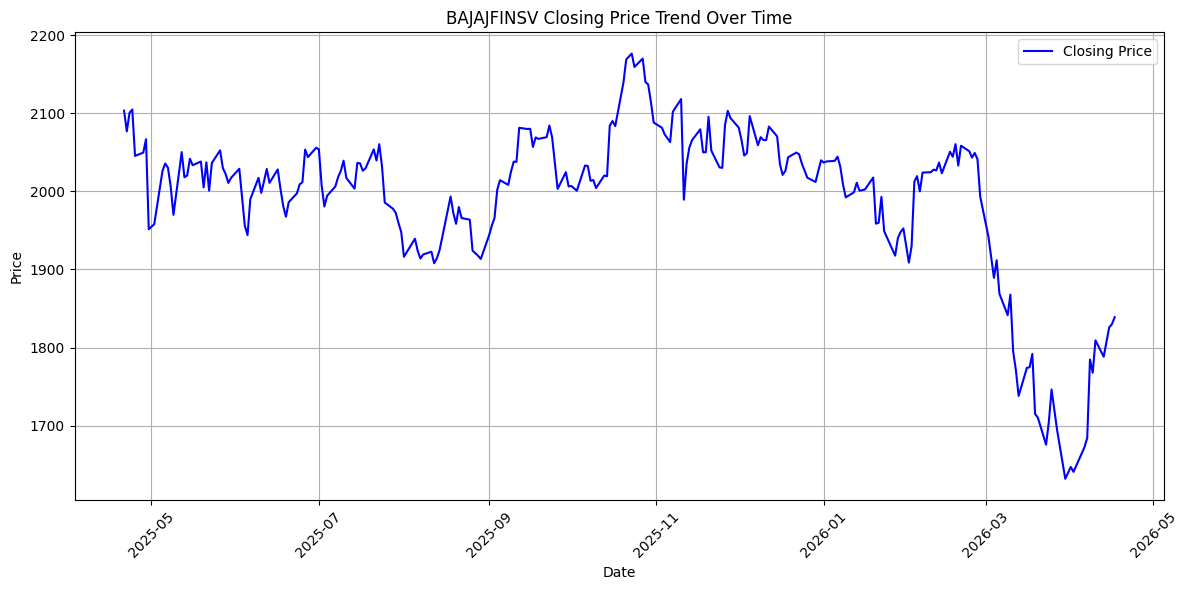

In [5]:
plt.figure(figsize=(12, 6))

# Identify columns dynamically
date_col = 'DATE' if 'DATE' in df.columns else 'Date'
close_col = [col for col in df.columns if 'CLOSE' in col.upper() and 'PREV' not in col.upper()][0]

plt.plot(df[date_col], df[close_col], label='Closing Price', color='blue')
plt.title(f'BAJAJFINSV Closing Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ARIMA Model Implementation
(a) Augmented Dickey-Fuller (ADF) Test for Stationarity

In [6]:
from statsmodels.tsa.stattools import adfuller

# Prepare the series
series = df[close_col]

def check_stationarity(timeseries):
    print('Results of Augmented Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)
    if dftest[1] <= 0.05:
        print("\nConclusion: Data is stationary (p <= 0.05)")
    else:
        print("\nConclusion: Data is non-stationary (p > 0.05). Differencing may be required.")

check_stationarity(series)

Results of Augmented Dickey-Fuller Test:
Test Statistic                  -2.139623
p-value                          0.228883
#Lags Used                       0.000000
Number of Observations Used    246.000000
Critical Value (1%)             -3.457215
Critical Value (5%)             -2.873362
Critical Value (10%)            -2.573070
dtype: float64

Conclusion: Data is non-stationary (p > 0.05). Differencing may be required.


### (b) ACF and PACF Plots
We use these plots to identify the orders of the AR (p) and MA (q) components.

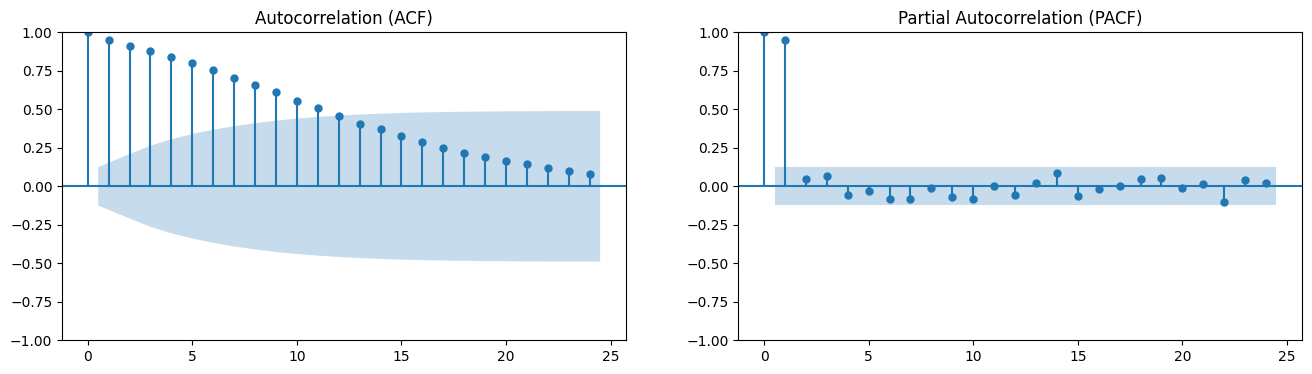

In [7]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Original Series
plot_acf(series, ax=axes[0], title='Autocorrelation (ACF)')
plot_pacf(series, ax=axes[1], title='Partial Autocorrelation (PACF)')

plt.show()

### (c) Fit ARIMA Model and Evaluate
I will use a simple (1,1,1) configuration as a baseline, but these parameters should be adjusted based on the plots above.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

Test RMSE: 150.935


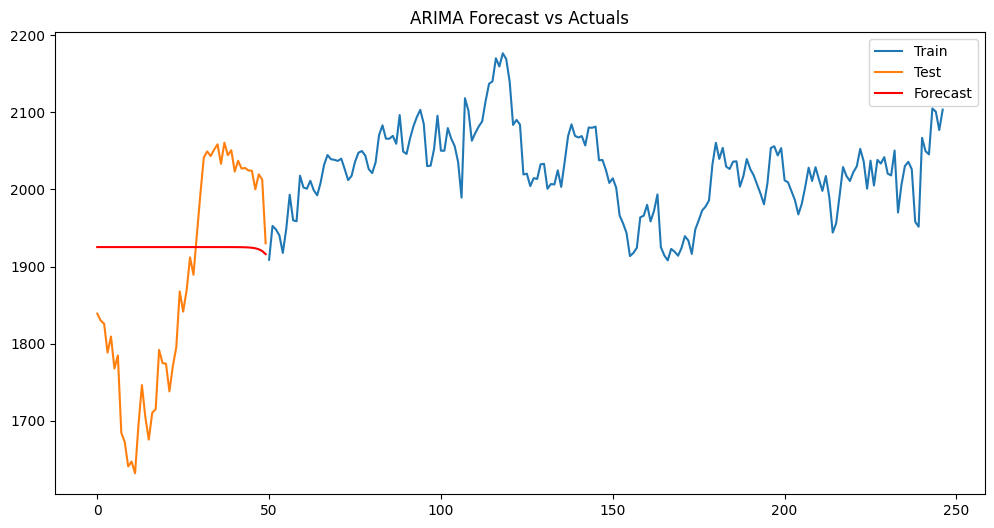

In [8]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# Split data into train and test (80/20)
size = int(len(series) * 0.8)
train, test = series[0:size], series[size:len(series)]

# Fit Model (p=1, d=1, q=1 as a starting point)
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

# Forecast
forecast_steps = len(test)
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast.summary_frame()['mean']

# Evaluation
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
print(f'Test RMSE: {rmse:.3f}')

# Plotting Forecast
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast_mean, label='Forecast', color='red')
plt.title('ARIMA Forecast vs Actuals')
plt.legend()
plt.show()

### Future Price Prediction (Next 30 Days)
(a) Forecast 30 days into the future using the ARIMA model.
(b) Visualize historical data alongside the forecast.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

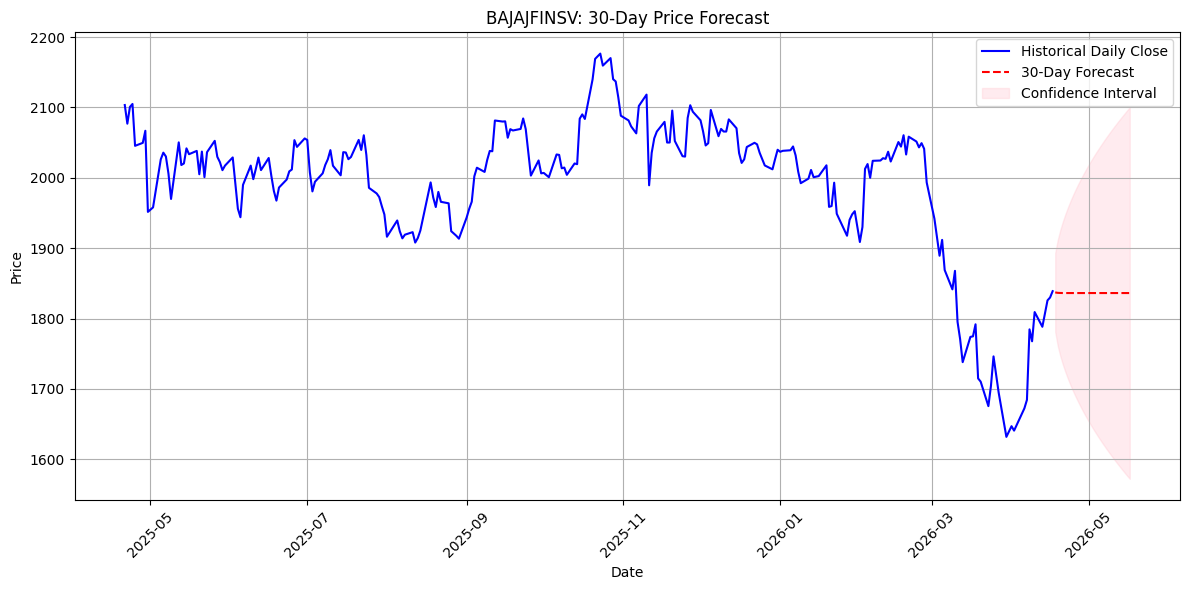

,Date,Forecasted_Price
0,2026-04-18,1837.116524
1,2026-04-19,1836.530626
2,2026-04-20,1836.338150
3,2026-04-21,1836.274919
4,2026-04-22,1836.254147
5,2026-04-23,1836.247323
6,2026-04-24,1836.245081
7,2026-04-25,1836.244345
8,2026-04-26,1836.244103
9,2026-04-27,1836.244023


In [9]:
# Re-fitting model on the full dataset for better future prediction
full_model = ARIMA(series, order=(1,1,1))
full_model_fit = full_model.fit()

# Forecast next 30 days
forecast_horizon = 30
future_forecast = full_model_fit.get_forecast(steps=forecast_horizon)
future_mean = future_forecast.summary_frame()['mean']
conf_int = future_forecast.summary_frame()[['mean_ci_lower', 'mean_ci_upper']]

# Create a date range for the future forecast
last_date = df[date_col].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_horizon)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df[date_col], df[close_col], label='Historical Daily Close', color='blue')
plt.plot(future_dates, future_mean, label='30-Day Forecast', color='red', linestyle='--')
plt.fill_between(future_dates, conf_int['mean_ci_lower'], conf_int['mean_ci_upper'], color='pink', alpha=0.3, label='Confidence Interval')

plt.title('BAJAJFINSV: 30-Day Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print forecast values
forecast_df = pd.DataFrame({'Date': future_dates, 'Forecasted_Price': future_mean.values})
display(forecast_df.head(10))